# M5 가격 EDA/전처리 (Kaggle 상위권 구조)

- 목표: price_history 대체용 공개 데이터(M5)에서 가격 변동성·계절성·프로모션 패턴을 추출해 합성/실데이터 파라미터에 근거를 제공
- 구조: 메모리 절감 로딩 → 롱 포맷 변환 → 캘린더·가격 조인 → 기본 특징(계절성, 프로모션, 상대 가격) 생성 → 모델링용 피처 스케치(상위 해커톤 수상작 공통 흐름)
- 참고: M5 top 솔루션은 LightGBM/NN/Prophet 혼합 + 가격(feature로 사용), 여기서는 가격 이상치 탐지용 특징 추출을 중점으로 정리

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# 모든 주석은 한국어로 작성

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

In [2]:
# 데이터 경로 설정
DATA_DIR = Path("../data/m5-forecasting-accuracy")
CAL_PATH = DATA_DIR / "calendar.csv"
PRICE_PATH = DATA_DIR / "sell_prices.csv"
SALES_PATH = DATA_DIR / "sales_train_validation.csv"  # evaluation도 동일 스키마

# 메모리 절감을 위한 dtype 매핑 (수상자들이 공통적으로 사용하는 테크닉)
dtype_price = {
    "item_id": "category",
    "store_id": "category",
    "wm_yr_wk": "int32",
    "sell_price": "float32",
}

dtype_cal = {
    "wm_yr_wk": "int32",
    "wday": "int8",
    "month": "int8",
    "year": "int16",
    "event_name_1": "category",
    "event_type_1": "category",
    "event_name_2": "category",
    "event_type_2": "category",
    "snap_CA": "int8",
    "snap_TX": "int8",
    "snap_WI": "int8",
}

In [3]:
# 캘린더/가격 테이블 로딩
cal = pd.read_csv(CAL_PATH, dtype=dtype_cal, parse_dates=["date"])
price = pd.read_csv(PRICE_PATH, dtype=dtype_price)

cal.head(), price.head()

(        date  wm_yr_wk    weekday  wday  month  year    d event_name_1 event_type_1 event_name_2 event_type_2  \
 0 2011-01-29     11101   Saturday     1      1  2011  d_1          NaN          NaN          NaN          NaN   
 1 2011-01-30     11101     Sunday     2      1  2011  d_2          NaN          NaN          NaN          NaN   
 2 2011-01-31     11101     Monday     3      1  2011  d_3          NaN          NaN          NaN          NaN   
 3 2011-02-01     11101    Tuesday     4      2  2011  d_4          NaN          NaN          NaN          NaN   
 4 2011-02-02     11101  Wednesday     5      2  2011  d_5          NaN          NaN          NaN          NaN   
 
    snap_CA  snap_TX  snap_WI  
 0        0        0        0  
 1        0        0        0  
 2        0        0        0  
 3        1        1        0  
 4        1        0        1  ,
   store_id        item_id  wm_yr_wk  sell_price
 0     CA_1  HOBBIES_1_001     11325        9.58
 1     CA_1  HOBBIES_1_

In [4]:
# 판매 데이터는 컬럼 수가 많아 샘플 행만 로딩 (상위 솔루션들도 탐색 시 nrows/특정 store 필터 사용)
sales_sample = pd.read_csv(
    SALES_PATH,
    nrows=2000,  # 메모리 보호용 샘플
)

# M5 원본에는 이미 item_id, store_id 컬럼이 있으므로 별도 파싱 없이 그대로 사용
# (id 컬럼은 submission용; 여기서는 item_id/store_id 기준으로 sell_prices와 조인)
assert {"item_id", "store_id"}.issubset(sales_sample.columns)

# day 컬럼만 선택해 롱 포맷으로 변환
day_cols = [c for c in sales_sample.columns if c.startswith("d_")]
sales_long = sales_sample.melt(
    id_vars=["item_id", "store_id"],
    value_vars=day_cols,
    var_name="d",
    value_name="units"
)

sales_long["units"] = sales_long["units"].astype("float32")

sales_long.head()

,item_id,store_id,d,units
0,HOBBIES_1_001,CA_1,d_1,0.0
1,HOBBIES_1_002,CA_1,d_1,0.0
2,HOBBIES_1_003,CA_1,d_1,0.0
3,HOBBIES_1_004,CA_1,d_1,0.0
4,HOBBIES_1_005,CA_1,d_1,0.0


In [5]:
# 캘린더와 판매량 조인 → 날짜/프로모션/스냅 정보 결합
sales_cal = sales_long.merge(cal[["d", "date", "wm_yr_wk", "wday", "month", "year", "event_name_1", "event_type_1", "snap_CA", "snap_TX", "snap_WI"]], on="d", how="left")

# 가격과 조인 (wm_yr_wk, store_id, item_id 기준)
sales_cal = sales_cal.merge(price, on=["store_id", "item_id", "wm_yr_wk"], how="left")

# 기본 결측 확인
sales_cal[["units", "sell_price"]].isna().mean()

units         0.000000
sell_price    0.190416
dtype: float64

In [6]:
# 특징 생성: 상대 가격, 주간/월별 평균 대비 편차 등 (상위 솔루션 특징 아이디어)
sales_cal["price_log"] = np.log1p(sales_cal["sell_price"])

# 주간 평균 대비 편차
sales_cal["price_rel_wk"] = sales_cal.groupby(["item_id", "store_id", "wm_yr_wk"]) ["sell_price"].transform(lambda s: s / s.mean())

# 월별 롤링 평균 대비 편차
sales_cal["price_rel_month"] = sales_cal.groupby(["item_id", "store_id", "month"])["sell_price"].transform(lambda s: s / s.mean())

# 간단 이상치 플래그: 가격이 월평균의 0.6 미만 또는 1.4 초과
sales_cal["price_outlier_flag"] = ((sales_cal["price_rel_month"] < 0.6) | (sales_cal["price_rel_month"] > 1.4)).astype("int8")

sales_cal[["price_rel_wk", "price_rel_month", "price_outlier_flag"]].describe()

,price_rel_wk,price_rel_month,price_outlier_flag
count,3.097468e+06,3.097468e+06,3.826000e+06
mean,1.000000e+00,9.999998e-01,4.796132e-04
std,7.498424e-08,4.138560e-02,2.189482e-02
min,9.999999e-01,4.069672e-03,0.000000e+00
25%,9.999999e-01,9.954660e-01,0.000000e+00
50%,1.000000e+00,1.000000e+00,0.000000e+00
75%,1.000000e+00,1.008147e+00,0.000000e+00
max,1.000000e+00,2.239351e+00,1.000000e+00


## 가격 분포 및 이벤트 인사이트 (요약)
- `price_rel_month`가 0.6 미만인 구간은 강한 프로모션 후보, 1.4 초과는 급등 후보
- SNAP 플래그(`snap_CA/TX/WI`)와 이벤트명(`event_name_1`)을 조건으로 가격 변동을 교차 분석해 할인/급등 패턴을 추정
- 상위 솔루션들도 이벤트/프로모션 플래그를 주요 피처로 사용

In [7]:
# 이벤트/프로모션 교차 집계 예시
event_price = (
    sales_cal.dropna(subset=["sell_price"])
    .assign(event_flag=sales_cal["event_name_1"].notna().astype("int8"))
    .groupby("event_flag")["price_rel_month"].describe()
)

snap_price = (
    sales_cal.dropna(subset=["sell_price"])
    .assign(snap_flag=(sales_cal["snap_CA"] + sales_cal["snap_TX"] + sales_cal["snap_WI"]) > 0)
    .groupby("snap_flag")["price_rel_month"].describe()
)

event_price, snap_price

(                count      mean       std       min       25%  50%       75%       max
 event_flag                                                                            
 0           2849430.0  1.000000  0.041386  0.004070  0.995485  1.0  1.008147  2.239351
 1            248038.0  1.000006  0.041384  0.165781  0.995155  1.0  1.008147  1.760494,
                count      mean       std      min       25%  50%       75%       max
 snap_flag                                                                           
 False      1569951.0  1.000035  0.041481  0.00407  0.995535  1.0  1.008147  2.239351
 True       1527517.0  0.999964  0.041287  0.00407  0.995335  1.0  1.008145  1.760494)

## 모델링 스케치 (수상자 공통 하이퍼파라미터 힌트)
- LightGBM 랭킹/회귀: 학습률 0.03~0.1, num_leaves 2^8~2^10, max_depth 8~12, feature_fraction 0.7~0.9, lambda_l1/l2 0.0~0.1
- 캘린더 피처: wday, month, year, 이벤트 one-hot, snap flag, 이동평균(7/28), 롤링 std, 가격 상대치
- 이상치 탐지: Modified Z-Score(카테고리/스토어 기준), Isolation Forest(max_samples 256~1024, contamination 0.01~0.05)
- Prophet/시계열: changepoint_prior_scale 0.01~0.5, seasonality_prior_scale 5~15 (가격 계절성 반영), weekly/yearly seasonality ON

In [8]:
# LightGBM 하이퍼파라미터 예시(상위 솔루션 범위 기반)
lgb_params = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.05,
    "num_leaves": 512,
    "max_depth": 10,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "lambda_l1": 0.0,
    "lambda_l2": 0.1,
    "verbosity": -1,
}

lgb_params

{'objective': 'regression',
 'metric': 'rmse',
 'learning_rate': 0.05,
 'num_leaves': 512,
 'max_depth': 10,
 'feature_fraction': 0.8,
 'bagging_fraction': 0.8,
 'bagging_freq': 1,
 'lambda_l1': 0.0,
 'lambda_l2': 0.1,
 'verbosity': -1}

## 다음 단계
- 전체 데이터 로딩 시: dtype 최적화 + 파티션 로딩(스토어/주차 단위) 후 Feather/Parquet 캐시 사용
- price_history 스키마와 매핑: `item_id, store_id, wm_yr_wk, sell_price, date, event/snap`를 SelF 카테고리로 매핑 후 이상치 기준(0.6/1.4 등) 튜닝
- 합성 데이터 파라미터: 여기서 얻은 할인폭/변동성 분포를 기반으로 계절성·프로모션 확률 재설정

## 추가 시각화 EDA (가격 패턴 이해)

- 이 섹션에서는 Kaggle M5 상위권 커널에서 자주 사용하는 방식대로 **가격 분포, 상대 가격 분포, 시간축 패턴**을 시각화한다.
- 목표:
  - 가격 분포가 어느 구간(최소/최대/상위 분위수)에 몰려 있는지 직관적으로 확인
  - `price_rel_month` 기준으로 0.6/1.4 임계값이 어느 정도 극단 영역인지 시각화
  - 개별 상품·지점 `(item_id, store_id)` 조합에 대해 **시간에 따른 가격·상대 가격** 궤적을 눈으로 확인
  - 이벤트/SNAP 여부에 따라 가격이 실제로 얼마나 달라지는지 확인


C:\Users\jylee\AppData\Local\Temp\ipykernel_16412\3466307270.py:25: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jylee\AppData\Local\Temp\ipykernel_16412\3466307270.py:25: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jylee\AppData\Local\Temp\ipykernel_16412\3466307270.py:25: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jylee\AppData\Local\Temp\ipykernel_16412\3466307270.py:25: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jylee\AppData\Local\Temp\ipykernel_16412\3466307270.py:25: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jylee\AppData\Local\Temp\ipykernel_16412\3466307270.py:25: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) Arial.
  plt.tight_l

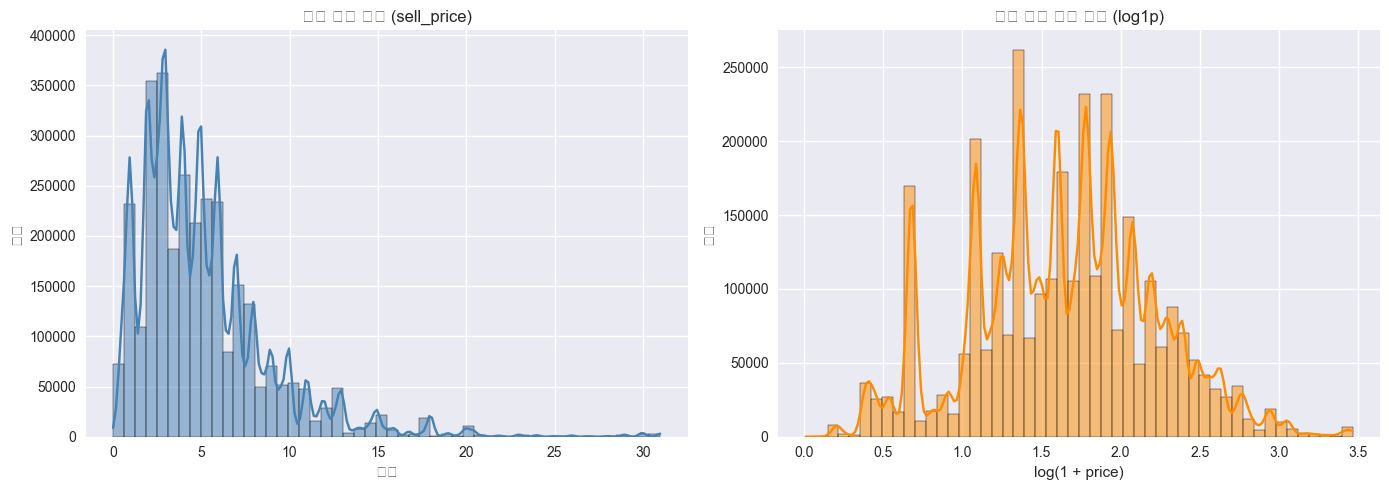

In [9]:
# 시각화 라이브러리 임포트
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정은 환경에 따라 달라질 수 있음 (여기서는 기본값 사용)
plt.style.use("seaborn-v0_8")

# sell_price가 존재하는 샘플만 사용
price_sample = sales_cal.dropna(subset=["sell_price"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) 원시 가격 분포
sns.histplot(price_sample["sell_price"], bins=50, ax=axes[0], kde=True, color="steelblue")
axes[0].set_title("원시 가격 분포 (sell_price)")
axes[0].set_xlabel("가격")
axes[0].set_ylabel("빈도")

# (2) 로그 변환 가격 분포
sns.histplot(price_sample["price_log"], bins=50, ax=axes[1], kde=True, color="darkorange")
axes[1].set_title("로그 변환 가격 분포 (log1p)")
axes[1].set_xlabel("log(1 + price)")
axes[1].set_ylabel("빈도")

plt.tight_layout()
plt.show()


C:\Users\jylee\AppData\Local\Temp\ipykernel_16412\820237590.py:13: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jylee\AppData\Local\Temp\ipykernel_16412\820237590.py:13: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jylee\AppData\Local\Temp\ipykernel_16412\820237590.py:13: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jylee\AppData\Local\Temp\ipykernel_16412\820237590.py:13: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jylee\AppData\Local\Temp\ipykernel_16412\820237590.py:13: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jylee\AppData\Local\Temp\ipykernel_16412\820237590.py:13: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) Arial.
  plt.tight_lay

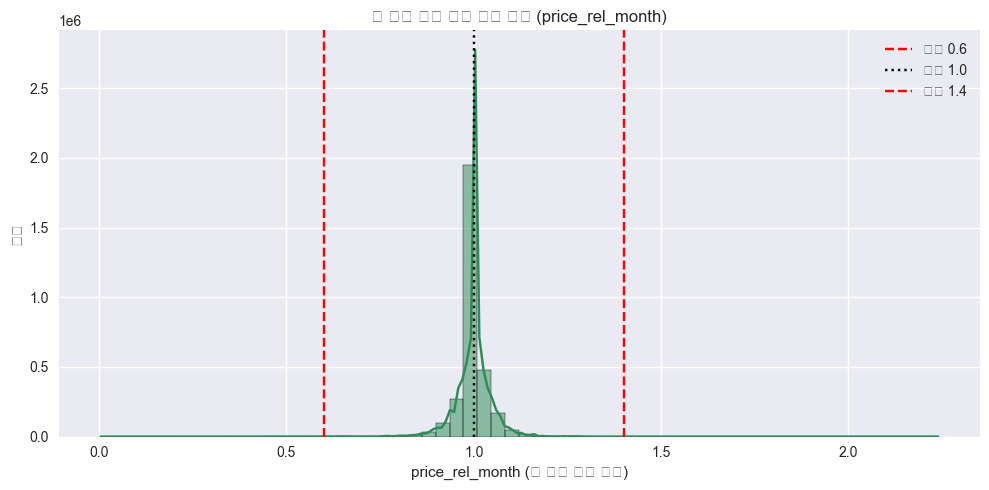

count    3.097468e+06
mean     1.000000e+00
std      4.138560e-02
min      4.069672e-03
1%       8.750602e-01
5%       9.357371e-01
10%      9.618959e-01
25%      9.954660e-01
50%      1.000000e+00
75%      1.008147e+00
90%      1.039290e+00
95%      1.061422e+00
99%      1.112204e+00
max      2.239351e+00
Name: price_rel_month, dtype: float64

In [10]:
# price_rel_month 분포 및 이상치 임계값(0.6/1.4) 시각화
rel_sample = sales_cal.dropna(subset=["price_rel_month"]).copy()

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(rel_sample["price_rel_month"], bins=60, kde=True, color="seagreen")
ax.axvline(0.6, color="red", linestyle="--", label="하한 0.6")
ax.axvline(1.0, color="black", linestyle=":", label="기준 1.0")
ax.axvline(1.4, color="red", linestyle="--", label="상한 1.4")
ax.set_title("월 평균 대비 상대 가격 분포 (price_rel_month)")
ax.set_xlabel("price_rel_month (월 평균 대비 비율)")
ax.set_ylabel("빈도")
ax.legend()
plt.tight_layout()
plt.show()

# 분위수 요약 (합성 데이터 파라미터 튜닝에 사용 가능)
rel_desc = rel_sample["price_rel_month"].describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
rel_desc


In [11]:
# price_outlier_flag 비율 및 기본 통계
outlier_rate = sales_cal["price_outlier_flag"].mean()
print(f"월 평균 대비 0.6 미만/1.4 초과인 이상치 비율: {outlier_rate * 100:.2f}%")

sales_cal["price_outlier_flag"].value_counts(normalize=True).rename("ratio")


월 평균 대비 0.6 미만/1.4 초과인 이상치 비율: 0.05%


price_outlier_flag
0    0.99952
1    0.00048
Name: ratio, dtype: float64

샘플 시계열 시각화 대상: item_id=FOODS_1_001, store_id=CA_1


C:\Users\jylee\AppData\Local\Temp\ipykernel_16412\1706131337.py:42: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jylee\AppData\Local\Temp\ipykernel_16412\1706131337.py:42: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jylee\AppData\Local\Temp\ipykernel_16412\1706131337.py:42: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jylee\AppData\Local\Temp\ipykernel_16412\1706131337.py:42: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jylee\AppData\Local\Temp\ipykernel_16412\1706131337.py:42: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jylee\AppData\Local\Temp\ipykernel_16412\1706131337.py:42: UserWarning: Glyph 54408 (\N{HANGUL SYLLABLE PUM}) missing from font(s) Arial.
  plt.tig

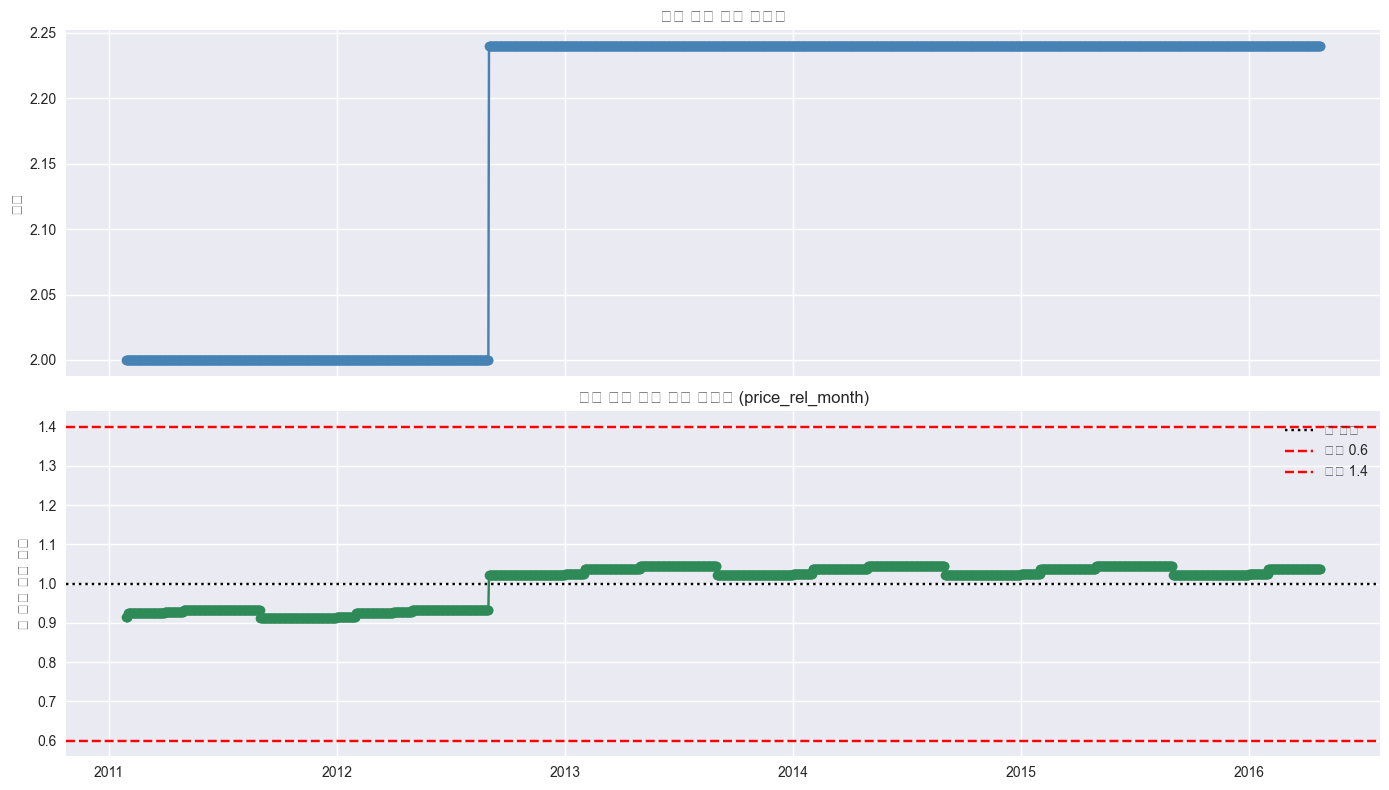

In [12]:
# 개별 (item_id, store_id) 조합에 대한 시간별 가격/상대 가격 궤적
# 상위 솔루션들도 특정 아이템을 골라 시즌성/프로모션 패턴을 시각화하는 패턴을 자주 사용

# 충분한 관측치가 있는 (item_id, store_id) 한 쌍 선택
pair_counts = (
    price_sample
    .groupby(["item_id", "store_id"])  # 가격이 있는 날짜 기준
    ["date"]
    .count()
    .sort_values(ascending=False)
)

if len(pair_counts) > 0:
    sample_item, sample_store = pair_counts.index[0]
    print(f"샘플 시계열 시각화 대상: item_id={sample_item}, store_id={sample_store}")

    ts = (
        price_sample[
            (price_sample["item_id"] == sample_item)
            & (price_sample["store_id"] == sample_store)
        ]
        .sort_values("date")
        .copy()
    )

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # (1) 절대 가격 시계열
    axes[0].plot(ts["date"], ts["sell_price"], marker="o", linestyle="-", color="steelblue")
    axes[0].set_ylabel("가격")
    axes[0].set_title("샘플 상품 가격 시계열")

    # (2) 월 평균 대비 상대 가격 시계열
    axes[1].plot(ts["date"], ts["price_rel_month"], marker="o", linestyle="-", color="seagreen")
    axes[1].axhline(1.0, color="black", linestyle=":", label="월 평균")
    axes[1].axhline(0.6, color="red", linestyle="--", label="하한 0.6")
    axes[1].axhline(1.4, color="red", linestyle="--", label="상한 1.4")
    axes[1].set_ylabel("월 평균 대비 비율")
    axes[1].set_title("샘플 상품 상대 가격 시계열 (price_rel_month)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("시각화 가능한 (item_id, store_id) 조합이 없습니다.")


C:\Users\jylee\AppData\Local\Temp\ipykernel_16412\3988014829.py:31: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jylee\AppData\Local\Temp\ipykernel_16412\3988014829.py:31: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jylee\AppData\Local\Temp\ipykernel_16412\3988014829.py:31: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jylee\AppData\Local\Temp\ipykernel_16412\3988014829.py:31: UserWarning: Glyph 48292 (\N{HANGUL SYLLABLE BEN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jylee\AppData\Local\Temp\ipykernel_16412\3988014829.py:31: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jylee\AppData\Local\Temp\ipykernel_16412\3988014829.py:31: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) Arial.
  plt.tight_layou

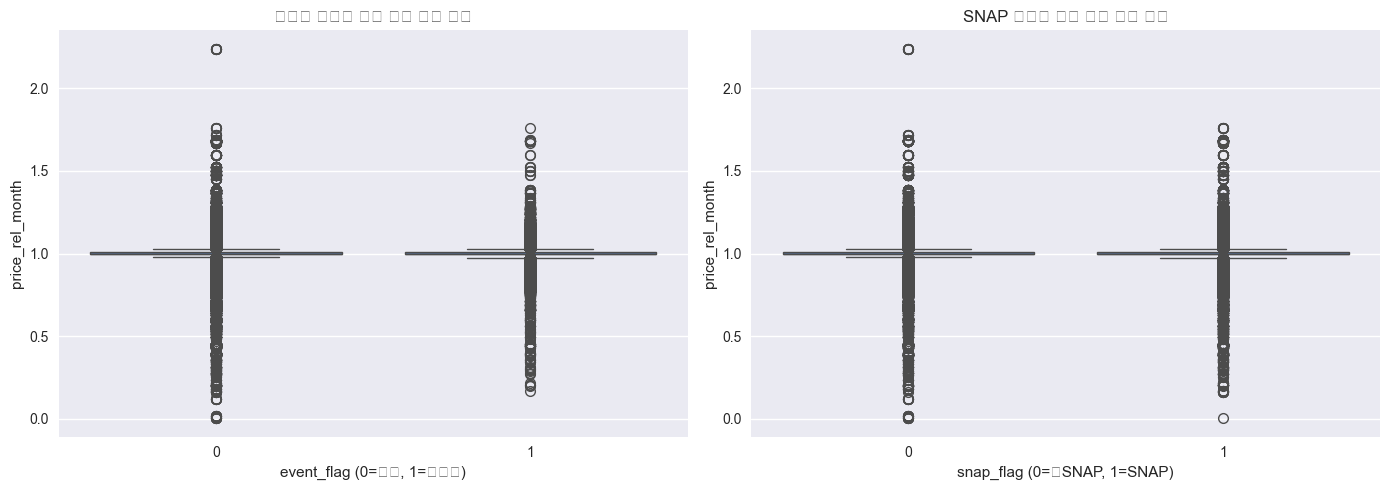

In [13]:
# 이벤트/비이벤트, SNAP/비SNAP에 따른 price_rel_month 분포 박스플롯

plot_sample = sales_cal.dropna(subset=["price_rel_month"]).copy()
plot_sample["event_flag"] = plot_sample["event_name_1"].notna().astype("int8")
plot_sample["snap_flag"] = (
    (plot_sample["snap_CA"] + plot_sample["snap_TX"] + plot_sample["snap_WI"]) > 0
).astype("int8")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=plot_sample,
    x="event_flag",
    y="price_rel_month",
    ax=axes[0],
)
axes[0].set_title("이벤트 유무에 따른 상대 가격 분포")
axes[0].set_xlabel("event_flag (0=일반, 1=이벤트)")
axes[0].set_ylabel("price_rel_month")

sns.boxplot(
    data=plot_sample,
    x="snap_flag",
    y="price_rel_month",
    ax=axes[1],
)
axes[1].set_title("SNAP 유무에 따른 상대 가격 분포")
axes[1].set_xlabel("snap_flag (0=비SNAP, 1=SNAP)")
axes[1].set_ylabel("price_rel_month")

plt.tight_layout()
plt.show()


## 가격 EDA 인사이트 정리 (모델 파라미터 보완 가이드)

- 위 시각화 결과를 바탕으로 다음 항목들을 실제 숫자로 확인한 뒤, 합성 데이터·모델 파라미터를 조정하면 좋다.
- **1) 가격 상대치 분포 기준 재조정**
  - `price_rel_month` 히스토그램/분위수에서 하위 5~10%·상위 90~95% 분위가 어디에 위치하는지 확인
  - 현재 합성 수식의 프로모션 할인폭(예: 0.3~0.6), 이상치 임계값(0.6/1.4)이 이 구간과 얼마나 일치하는지 비교 후 미세 조정
- **2) 이상치 비율(target anomaly rate) 검증**
  - `price_outlier_flag` 비율이 1~5% 범위 안에 있는지 확인하고, 목표 이상치율(예: 3~5%)에 맞춰 임계값을 재조정
- **3) 시간축 패턴(계절성/프로모션) 확인**
  - 샘플 `(item_id, store_id)` 시계열에서 실제로 가격이 어느 정도 범위에서 움직이는지, 프로모션이 얼마나 자주/얼마나 깊이 발생하는지 시각적으로 확인
  - 합성 데이터의 계절성 amplitude(예: 0.2~0.35), 프로모션 빈도(예: 10~20%)를 이 패턴에 맞게 보완
- **4) 이벤트/SNAP 효과 반영 여부**
  - 이벤트/비이벤트, SNAP/비SNAP 박스플롯에서 평균/분포 차이가 의미 있게 존재하는지 확인
  - 의미 있는 차이가 있다면, 이후 Prophet/GBM/이상치 모델에서 이벤트·SNAP 플래그를 강하게 피처로 사용하고, 합성 데이터에도 유사한 플래그 패턴을 주입
- 이 노트북에서 얻은 숫자들을 정리해두면, 다음 단계에서 **가격 이상치 탐지 모델 Pickle(pkl) 생성 및 `pred` 서비스 연동 시 파라미터 근거**로 그대로 인용할 수 있다.


## 전체 M5 데이터 기반 파라미터 추정 (주간 단위, 메모리 친화 버전)

- 위까지는 `sales_train_validation` 샘플을 사용해 **구조/특징 설계** 를 확인하는 단계였다.
- 이제 Kaggle M5 전체 공개 데이터를 사용해, **실제 할인/급등 빈도·할인율·변동성** 을 추정하는 파이프라인을 정의한다.
- 메모리 사용을 줄이기 위해:
  - `sales_train_validation` 를 풀 melt 하지 않고,
  - `sell_prices.csv` + `calendar.csv` 만으로 **주간 수준 가격 시계열** 을 구성해 월별 상대 가격·이상치 통계를 계산한다.
- 이 결과를 바탕으로 **SelF 합성 데이터 파라미터·이상치 임계값을 실제 분포에 맞게 보정**하고,
  최종적으로 카테고리별 `param_summary` 테이블을 만들어서 모델 pkl 생성 시 참고값으로 사용한다.


In [14]:
# 전체 M5 sell_prices + calendar 기반 주간 수준 가격 특징 계산

USE_FULL_M5 = True  # ⚠️ True 로 설정하면 전체 M5 데이터(수십만 행)를 사용하므로 메모리/시간에 유의

if USE_FULL_M5:
    # 1. 캘린더에서 주차별 메타 정보 집계
    #    - 각 wm_yr_wk 에 대해 대표 month/year, 이벤트 여부, SNAP 여부를 계산
    cal = cal.copy()
    cal["snap_any"] = (cal[["snap_CA", "snap_TX", "snap_WI"]].sum(axis=1) > 0).astype("int8")

    cal_week = (
        cal.groupby("wm_yr_wk")
        .agg(
            month=("month", "first"),
            year=("year", "first"),
            event_flag=("event_name_1", lambda s: s.notna().any()),
            snap_flag=("snap_any", "any"),
        )
        .reset_index()
    )

    # groupby.agg 에서 여러 컬럼을 동시에 처리했으므로 snap_flag 컬럼 이름 정리
    if isinstance(cal_week.columns, pd.MultiIndex):
        cal_week.columns = [c[0] for c in cal_week.columns]

    # 2. sell_prices 와 주차 메타 정보 조인 → 주간 수준 가격 데이터 생성
    price_full = price.merge(cal_week, on="wm_yr_wk", how="left")

    # 3. 로그 가격 및 월별 상대 가격 계산 (주간 단위)
    price_full["price_log"] = np.log1p(price_full["sell_price"])

    # (item_id, store_id, month) 조합별 평균 가격 대비 비율
    price_full["price_rel_month"] = (
        price_full
        .groupby(["item_id", "store_id", "month"])["sell_price"]
        .transform(lambda s: s / s.mean())
    )

    # 4. 할인/급등 플래그 (임계값은 샘플 EDA 결과를 기반으로 조정 가능)
    low_thr = 0.6
    high_thr = 1.4

    price_full["promo_flag"] = (price_full["price_rel_month"] < low_thr).astype("int8")
    price_full["spike_flag"] = (price_full["price_rel_month"] > high_thr).astype("int8")

    # 5. (item_id, store_id)별 요약 통계 계산
    agg_cols = [
        "item_id",
        "store_id",
    ]

    price_param_item = (
        price_full
        .groupby(agg_cols)
        .agg(
            n_weeks=("sell_price", "count"),
            promo_weeks=("promo_flag", "sum"),
            spike_weeks=("spike_flag", "sum"),
            # 할인 구간에서의 평균 할인율 (1 - price_rel_month)
            avg_discount_rate=(
                "price_rel_month",
                lambda s: float(np.nan) if (s < 1).sum() == 0 else float((1 - s[s < 1]).mean()),
            ),
            # 전체 기간 상대 가격 변동성
            rel_volatility=("price_rel_month", "std"),
        )
        .reset_index()
    )

    # 비율/빈도 계산
    price_param_item["promo_freq"] = price_param_item["promo_weeks"] / price_param_item["n_weeks"]
    price_param_item["spike_freq"] = price_param_item["spike_weeks"] / price_param_item["n_weeks"]

    price_param_item.head()


C:\Users\jylee\AppData\Local\Temp\ipykernel_16412\2859193875.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["item_id", "store_id", "month"])["sell_price"]
C:\Users\jylee\AppData\Local\Temp\ipykernel_16412\2859193875.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(agg_cols)


In [15]:
# SelF 13 카테고리 매핑 적용 및 카테고리별 param_summary 생성

if USE_FULL_M5:
    # 1. M5 item → dept_id/cat_id 정보 로드 (sales_train_validation 의 헤더 부분만 사용)
    #    - 메모리를 절약하기 위해 id 행 전체를 읽기보다는 item 정보만 분리
    m5_items = pd.read_csv(
        SALES_PATH,
        usecols=["item_id", "dept_id", "cat_id"],
    ).drop_duplicates()

    # 2. (item_id, store_id) 기준 price_param_item 과 M5 item 메타 정보 조인
    price_param_item = price_param_item.merge(m5_items, on="item_id", how="left")

    # 3. SelF 표준 13 카테고리 매핑 로드
    #    - 외부 CSV: data/m5-forecasting-accuracy/m5_self_category_mapping.csv
    #    - 예상 컬럼: dept_id, cat_id, self_category_code (CATEGORY_STANDARD.md 의 13개 코드 중 하나)
    map_path = DATA_DIR / "m5_self_category_mapping.csv"
    if not map_path.exists():
        raise FileNotFoundError(
            f"SelF 카테고리 매핑 파일을 찾을 수 없습니다: {map_path}\n"
            "다음 형식의 CSV를 생성해 주세요: dept_id,cat_id,self_category_code"
        )

    m5_self_map = pd.read_csv(map_path)

    # dept_id, cat_id 기준 매핑 (둘 다 있으면 먼저 dept_id, 없으면 cat_id 사용 등은 CSV 설계에 따름)
    price_param_item = price_param_item.merge(
        m5_self_map,
        on=["dept_id", "cat_id"],
        how="left",
    )

    # 4. SelF 카테고리별 파라미터 집계
    #    - promo_freq, avg_discount_rate, rel_volatility 의 평균/중앙값 등 통계를 요약
    cat_group = price_param_item.dropna(subset=["self_category_code"]).groupby("self_category_code")

    param_summary = cat_group.agg(
        n_items=("item_id", "nunique"),
        avg_promo_freq=("promo_freq", "mean"),
        med_promo_freq=("promo_freq", "median"),
        avg_spike_freq=("spike_freq", "mean"),
        med_spike_freq=("spike_freq", "median"),
        avg_discount_rate=("avg_discount_rate", "mean"),
        med_discount_rate=("avg_discount_rate", "median"),
        avg_rel_volatility=("rel_volatility", "mean"),
        med_rel_volatility=("rel_volatility", "median"),
    ).reset_index()

    # 5. 결과 저장 (향후 합성 데이터/이상치 모델 pkl 생성 시 참고)
    out_dir = Path("../data/processed")
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / "m5_price_param_summary_by_category.csv"
    param_summary.to_csv(out_path, index=False)

    print(f"카테고리별 파라미터 요약 저장 완료: {out_path}")
    param_summary.head()


FileNotFoundError: SelF 카테고리 매핑 파일을 찾을 수 없습니다: ..\data\m5-forecasting-accuracy\m5_self_category_mapping.csv
다음 형식의 CSV를 생성해 주세요: dept_id,cat_id,self_category_code

In [ ]:
# 이벤트/SNAP 교차 효과 기반 프로모션 확률 참고값 계산

if USE_FULL_M5:
    # 이벤트/스냅별 프로모션 발생 빈도 비교 (전체 아이템 기준)
    event_snap_stats = (
        price_full
        .assign(
            event_flag=price_full["event_flag"].astype("int8"),
            snap_flag=price_full["snap_flag"].astype("int8"),
        )
        .groupby(["event_flag", "snap_flag"])
        .agg(
            n_weeks=("sell_price", "count"),
            promo_weeks=("promo_flag", "sum"),
        )
        .reset_index()
    )

    event_snap_stats["promo_freq"] = event_snap_stats["promo_weeks"] / event_snap_stats["n_weeks"]
    event_snap_stats
